This document contains the theory of modeling AOM Phase transients.  

We wish to compute $\langle E_f | U E_c \rangle$, where $E_f$ is the mode of the fiber and is essentially the 00 Hermite-Gaussian mode, denoted $u_{00}$, $U$ is the composite unitary operation that includes mirrors, free-space propagation, and lens. From the definition of the adjoint, we have $\langle E_f | U E_c \rangle = \langle U^\dagger E_f | E_c \rangle$. Since $U$ is unitary we have $U^\dagger = U^{-1}$, and therefore $\langle U^\dagger E_f | E_c \rangle = \langle U^{-1} E_f | E_c \rangle$.

This equality implies that to compute this overlap, we can propagate the fiber mode $E_f$ back until the exit face of the AOM, and take the inner product with the clipped Gaussian $E_c$. This method, compared to the original method of propagating the clipped Gaussian, has the advantage that the fiber mode $E_f$ is a simple Gaussian whose behavior through a lens and in free space propagation is well-known. 

The case of angular misalignment corresponds to the case that $E_f$ is tilted. In such cases we first project $E_f$ onto higher order $HG$ modes, examine high each mode propagates backwards, then combine at the AOM exit face before taking the inner product.

Onece we have $\langle E_f | U E_c \rangle$ as a function of time, we simply take the argument to extract $\phi(t)$.




Suppose that the misalignment angle is $\theta$. We know that any misalignment can be expressed as a coordinate rotation in the xz plane. Then, if we still look at the electric field in the focal plane, we get the following equation: 

$$E(x,y,0) = E_0 \exp[-(x^2 + y^2)/w_0^2] \exp(i k x \sin\theta),$$

where we have ignored the transformation on $x$ since it should be $x \cos(\theta)$, and then its squared so it would be a second-order effect.


The HG modes at who all have waist $w_0$ and propogate along the original z-direction can be expressed as:
$$u_{mn}(x,y,0) = \sqrt{\frac{2}{\pi w_0^2 2^{m+n} m! n!}} \, H_m\left(\sqrt{2} \, \frac{x}{w_0}\right) H_n\left(\sqrt{2} \, \frac{y}{w_0}\right) \exp\left[-(x^2 + y^2)/w_0^2\right]$$

We can then express $E(x, y, 0)$ as a linear combination of these HG modes:

$$E(x,y,0) = \sum_{m,n=0}^\infty c_{mn} u_{mn}(x,y,0)$$

with coefficients given by

$$c_{mn} = \iint E(x,y,0) u_{mn}^*(x,y,0) \, dx \, dy$$

Carrying out this calculation we get that
$$c_{mn} = \iint E_0 \exp\left[-\frac{x^2 + y^2}{w_0^2} + i k x \sin\theta\right] \sqrt{\frac{2}{\pi w_0^2 2^{m+n} m! n!}} \, H_m\left(\sqrt{2} \frac{x}{w_0}\right) H_n\left(\sqrt{2} \frac{y}{w_0}\right) \exp\left[-\frac{x^2 + y^2}{w_0^2}\right] \, dx \, dy$$

This integral can be separated into x and y integrals:
$$c_{mn} = E_0 \sqrt{\frac{2}{\pi w_0^2 2^{m+n} m! n!}} \int_{-\infty}^\infty \exp\left[-\frac{2x^2}{w_0^2} + i k x \sin\theta\right] H_m\left(\sqrt{2} \frac{x}{w_0}\right) \, dx \cdot \int_{-\infty}^\infty \exp\left[-\frac{2y^2}{w_0^2}\right] H_n\left(\sqrt{2} \frac{y}{w_0}\right) \, dy$$

Note that the integral in the y-direction, after a change of variables, becomes:
$$I_y(n) = \frac{w_0}{\sqrt{2}} \int_{-\infty}^\infty \exp(-\eta^2) H_n(\eta) \, d\eta.$$

From the Wikipedia page on Hermite polynomials, we find that 
$$\int_{-\infty}^\infty \exp(-\eta^2) H_n(\eta) H_{n'}(\eta) \, d\eta = \sqrt{\pi} \, 2^n n! \, \delta_{nn'}.$$

Since $H_0(\eta) = 1$, we have:
$$\int_{-\infty}^\infty \exp(-\eta^2) H_n(\eta) \, d\eta = \int_{-\infty}^\infty \exp(-\eta^2) H_n(\eta) H_0(\eta) \, d\eta = \sqrt{\pi} \, 2^0 0! \, \delta_{n0} = \sqrt{\pi} \, \delta_{n0}.$$

Thus, 
$$I_y(n) = (w_0 / \sqrt{2}) \sqrt{\pi} \, \delta_{n0},$$
so $c_{mn} = 0$ for $n \neq 0$

For the integral in the x-direction: 
$$I_x = \int_{-\infty}^\infty \exp\left(-\frac{2x^2}{w_0^2} + i k x \sin\theta\right) H_m\left(\sqrt{2} \frac{x}{w_0}\right) \, dx.$$
the result (from Mathematica) is:
$$I_x = \frac{w_0}{\sqrt{2}} \sqrt{\pi} \exp\left( -\frac{\beta^2}{4} \right) (i \beta)^m,$$
where
$$\beta = \frac{k w_0 \sin\theta}{\sqrt{2}}.$$

We may check that this formula is correct by comparing against numerical results in the code-block below:

In [3]:
import numpy as np
from scipy.integrate import quad
from scipy.special import hermite
import math

def integrand_real(x, w0, k, theta, m):
    arg = np.sqrt(2) * x / w0
    H = hermite(m)(arg)
    exp_part = np.exp(-2*x**2 / w0**2 + 1j * k * x * np.sin(theta))
    return np.real(exp_part * H)

def integrand_imag(x, w0, k, theta, m):
    arg = np.sqrt(2) * x / w0
    H = hermite(m)(arg)
    exp_part = np.exp(-2*x**2 / w0**2 + 1j * k * x * np.sin(theta))
    return np.imag(exp_part * H)

def numerical_integral(w0, k, theta, m, limit_factor=10):
    """
    Adapted to use finite limits [-a, a] where a = limit_factor * w0,
    since for small w0 the Gaussian is very narrow, and quad over infinite
    limits may fail to capture the integral accurately due to sampling issues.
    A limit_factor of 10 ensures the tails are negligible (exp(-200) ~ 0).
    """
    a = limit_factor * w0
    real_part = quad(integrand_real, -a, a, args=(w0, k, theta, m))[0]
    imag_part = quad(integrand_imag, -a, a, args=(w0, k, theta, m))[0]
    return real_part + 1j * imag_part

def analytical_integral(w0, k, theta, m):
    i_m = (1j)**m
    sqrt_part = np.sqrt(np.pi * w0**2 / 2)
    pow_part = (k * w0 * np.sin(theta) / np.sqrt(2))**m
    exp_part = np.exp( - (k**2 * w0**2 * np.sin(theta)**2)/8 )
    return i_m * sqrt_part * pow_part * exp_part

# Specific values
values = [
    {'w0': 1.65e-6, 'k': 2 * np.pi / 488e-9, 'theta': 0.005, 'm': 1},
    {'w0': 1.0, 'k': 1.0, 'theta': np.pi/4, 'm': 1},
    {'w0': 1.0, 'k': 1.0, 'theta': np.pi/4, 'm': 2},
    {'w0': 2.0, 'k': 0.5, 'theta': np.pi/6, 'm': 0},
    {'w0': 2.0, 'k': 0.5, 'theta': np.pi/6, 'm': 3}
]

results = []
for val in values:
    num = numerical_integral(**val)
    ana = analytical_integral(**val)
    diff = np.abs(num - ana)
    results.append({
        'params': val,
        'numerical': num,
        'analytical': ana,
        'difference': diff
    })

print(results)

[{'params': {'w0': 1.65e-06, 'k': 12875379.72782702, 'theta': 0.005, 'm': 1}, 'numerical': 1.5510598371702152e-07j, 'analytical': 1.5510598372076104e-07j, 'difference': 3.7395181132297275e-18}, {'params': {'w0': 1.0, 'k': 1.0, 'theta': 0.7853981633974483, 'm': 1}, 'numerical': 0.5886898362014917j, 'analytical': 0.5886898362014915j, 'difference': 2.220446049250313e-16}, {'params': {'w0': 1.0, 'k': 1.0, 'theta': 0.7853981633974483, 'm': 2}, 'numerical': (-0.2943449181007452+0j), 'analytical': (-0.29434491810074576+0j), 'difference': 5.551115123125783e-16}, {'params': {'w0': 2.0, 'k': 0.5, 'theta': 0.5235987755982988, 'm': 0}, 'numerical': (2.429507430250463+0j), 'analytical': (2.429507430250462+0j), 'difference': 8.881784197001252e-16}, {'params': {'w0': 2.0, 'k': 0.5, 'theta': 0.5235987755982988, 'm': 3}, 'numerical': -0.10737007367957357j, 'analytical': -0.10737007367957523j, 'difference': 1.6514567491299204e-15}]


Therefore, combining everything together, and assuming that $E_0 = \sqrt{2/(\pi w_0^2)}$ for normalization, we have:
$$c_m = \exp\left(-\frac{\beta^2}{4}\right) \frac{(i \beta)^m}{\sqrt{2^m m!}},$$
By setting $\alpha = i \beta / \sqrt{2}$, we can also write this formula in harmonic oscillator form:
$$c_m = \frac{1}{\sqrt{2^m m!}} \exp\left( -\frac{\beta^2}{4} \right) (i \beta)^m = \exp\left( -\frac{|\alpha|^2}{2} \right) \frac{\alpha^m \sqrt{2^m}}{\sqrt{2^m m!}} = \exp\left( -\frac{|\alpha|^2}{2} \right) \frac{\alpha^m}{\sqrt{m!}}.$$
For small angles, we have the approximation (ignoring terms above second order):
$$\exp\left(-\frac{|\alpha|^2}{2}\right) \approx 1 - \frac{|\alpha|^2}{2}, \quad c_0 \approx 1 - \frac{|\alpha|^2}{2}, \quad c_1 \approx \alpha, \quad c_m \approx 0 \ (m \geq 2).$$
And therefore
$$E(x,y,0) \approx  \left(1 - \frac{|\alpha|^2}{2}\right) \, u_{00}(x,y,0) + (\alpha) \, u_{10}(x,y,0) = \left(1 - \frac{k^2 w_0^2 \sin^2{\theta}}{8}\right) u_{00}(x,y,0) + \left(i\frac{kw_0\sin{\theta}}{2}\right) u_{10}(x,y,0),$$

In the above derivation, we assumed that the waist of the laser beam and the waist of the $HG$ modes are the same (i.e. all equal to $w_0$). However, if they are not, then we rederive analytically below:

Below is a fully self-contained derivation of the expansion coefficients

$$
E(x,y,0)\;=\;E_0\,
   e^{-\,(x^{2}+y^{2})/w_{0}^{2}}\,
   e^{\,i k x\sin\theta}
   \;=\;\sum_{m,n=0}^{\infty} c_{mn}\,u_{mn}(x,y,0)
$$

when the **true beam waist** is $w_{0}$ but the **Hermite–Gaussian (HG) basis waist** is
$w_{0}^{\prime}\neq w_{0}$.
All symbols are defined where they first appear and the final expressions
reduce to the familiar special cases
$(w_{0}^{\prime}=w_{0})$ or $(\theta=0)$.

---

### 1.  HG basis with waist $w_{0}^{\prime}$

$$
u_{mn}(x,y,0)=
  \sqrt{\frac{2}{\pi\,w_{0}^{\prime 2}\,2^{m+n}m!\,n!}}\;
  H_{m}\!\Bigl(\tfrac{\sqrt2\,x}{w_{0}^{\prime}}\Bigr)\,
  H_{n}\!\Bigl(\tfrac{\sqrt2\,y}{w_{0}^{\prime}}\Bigr)\,
  e^{-\,(x^{2}+y^{2})/w_{0}^{\prime 2}}.
$$

These modes are orthonormal in the transverse plane.

To find the expansion coefficients

$$
c_{mn}=\iint_{-\infty}^{\infty}
         E(x,y,0)\,u_{mn}^{*}(x,y,0)\,dx\,dy,
$$

insert $E$ and $u_{mn}$.  The Gaussian factors separate the integral:

$$
c_{mn}=E_{0}\,
        \sqrt{\frac{2}{\pi w_{0}^{\prime 2}\,2^{m+n}m!n!}}\;
        I_x(m)\;I_y(n),
$$

with

$$
\begin{aligned}
I_x(m)&=\int_{-\infty}^{\infty}
         e^{-q x^{2}+s x}\,H_{m}(\alpha x)\,dx,\\[4pt]
I_y(n)&=\int_{-\infty}^{\infty}
         e^{-q y^{2}}\,H_{n}(\alpha y)\,dy,
\end{aligned}
$$

and the shorthand constants

$$
q=\frac{1}{w_{0}^{2}}+\frac{1}{w_{0}^{\prime 2}},\qquad
\alpha=\frac{\sqrt2}{w_{0}^{\prime}},\qquad
s=i\,k\sin\theta.
$$

For later convenience define the **waist-mismatch** and **tilt** parameters

$$
\boxed{\;
\Delta=\frac{\alpha^{2}}{q}-1
      =-\frac{w_{0}^{\prime 2}-w_{0}^{2}}{w_{0}^{\prime 2}+w_{0}^{2}},\qquad
\mu=\frac{\alpha\,s}{q}
    =i\,k\sin\theta\,
      \frac{\sqrt2\,w_{0}^{2}w_{0}^{\prime}}{w_{0}^{\prime 2}+w_{0}^{2}}.}
$$

---

### 2.  The $y$-integral $I_y(n)$

Using the generating function
$e^{2\alpha y\,t-t^{2}}=\sum_{n=0}^{\infty}H_{n}(\alpha y)\,t^{n}/n!$,

$$
I_y(n)=
  \frac{\partial^{n}}{\partial t^{n}}
  \bigl[\sqrt{\tfrac{\pi}{q}}\,
        e^{-t^{2}}\,
        e^{\Delta t^{2}}\bigr]_{t=0}.
$$

Only **even** orders survive:

$$
I_y(n)=
\begin{cases}
\displaystyle
\sqrt{\dfrac{\pi}{q}}\;
\dfrac{(2p)!}{p!}\,\Delta^{\,p}, & n=2p,\\[10pt]
0, & n\ \text{odd}.
\end{cases}
\tag{1}
$$

---

### 3.  The $x$-integral $I_x(m)$

Insert the same generating function but keep the linear phase $s x$:

$$
\int_{-\infty}^{\infty}
  e^{-q x^{2}+s x}\,e^{2\alpha x\,t-t^{2}}\,dx
 =\sqrt{\frac{\pi}{q}}\,
   e^{-t^{2}}\,
   e^{\tfrac{(s+2\alpha t)^{2}}{4q}}.
$$

Differentiate $m$ times with respect to $t$ and set $t=0$.
A brief combinatorial re-arrangement gives

$$
I_x(m)=
\sqrt{\frac{\pi}{q}}\,
e^{-s^{2}/4q}\,
m!\sum_{j=0}^{\lfloor m/2\rfloor}
     \frac{\Delta^{\,j}}{j!}\,
     \frac{\mu^{\,m-2j}}{(m-2j)!}.
\tag{2}
$$

When $w_{0}^{\prime}\to w_{0}$ one has $\Delta\to0$ and only the $j=0$ term remains, reproducing the standard tilted-beam result.

---

### 4.  Expansion coefficients $c_{mn}$

Because $I_y(n)$ vanishes for odd $n$, write $n=2p\;(p\in\mathbb{N})$.
Inserting (1) and (2) into $c_{mn}$ yields

$$
\begin{aligned}
c_{m,\,2p}
 &=E_0\,
   \sqrt{\frac{2}{\pi w_{0}^{\prime 2}\,2^{m+2p}m!(2p)!}}
   \left(\sqrt{\frac{\pi}{q}}\right)^{2}
   e^{-s^{2}/4q}\,
   m!\,
   \frac{(2p)!}{p!}\,
   \Delta^{\,p}\,
   \sum_{j=0}^{\lfloor m/2\rfloor}
     \frac{\Delta^{\,j}}{j!}\,
     \frac{\mu^{\,m-2j}}{(m-2j)!}\\[8pt]
 &=
   E_0\,\frac{\pi}{q}\,
   \frac{e^{-s^{2}/4q}}{w_{0}^{\prime}\,2^{(m+2p)/2}}
   \;\frac{(2p)!^{1/2}}{p!\,m!^{1/2}}
   \,\Delta^{\,p}\,
   \sum_{j=0}^{\lfloor m/2\rfloor}
     \frac{\Delta^{\,j}\,\mu^{\,m-2j}}{j!\,(m-2j)!}.
\end{aligned}
\tag{3}
$$

---

### 5.  Consistency checks

* **No waist mismatch** ($w_{0}^{\prime}=w_{0}\Rightarrow\Delta=0$)

  $$
  c_{m0}=E_{0}\,
         e^{-k^{2}w_{0}^{2}\sin^{2}\theta/8}\,
         \frac{\bigl(i k w_{0}\sin\theta/\sqrt2\bigr)^{m}}
              {\sqrt{2^{\,m}m!}},
  \qquad c_{mn}=0\; (n\neq0),
  $$

  reproducing the original tilt-only expansion.

* **No tilt** ($\theta=0\Rightarrow \mu=0$)
  only even **total order** $m+n$ survives, encoding the familiar
  “squeezed-vacuum’’ pattern generated by a pure waist mismatch.

Equation (3) therefore gives the **correct and complete** coefficient set $c_{mn}$ for an arbitrarily tilted Gaussian beam when the analysis basis uses a different waist.

The integrals $I_x(m)$ and $I_y(n)$ are checked against numerical results below and are confirmed to be correct.

In [4]:
import numpy as np
from scipy.integrate import quad
from scipy.special import hermite

def integrand_real(y, w0, w0_mode, n):
    arg = np.sqrt(2) * y / w0_mode
    H = hermite(n)(arg)
    exp_part = np.exp(-(1/w0**2 + 1/w0_mode**2)*y**2)
    return np.real(exp_part * H)

def integrand_imag(y, w0, w0_mode, n):
    arg = np.sqrt(2) * y / w0_mode
    H = hermite(n)(arg)
    exp_part = np.exp(-(1/w0**2 + 1/w0_mode**2)*y**2)
    return np.imag(exp_part * H)

def numerical_integral(w0, w0_mode, n, limit_factor=10):
    """
    Adapted to use finite limits [-a, a] where a = limit_factor * w0,
    since for small w0 the Gaussian is very narrow, and quad over infinite
    limits may fail to capture the integral accurately due to sampling issues.
    A limit_factor of 10 ensures the tails are negligible (exp(-200) ~ 0).
    """
    a = limit_factor * w0_mode
    real_part = quad(integrand_real, -a, a, args=(w0, w0_mode, n))[0]
    imag_part = quad(integrand_imag, -a, a, args=(w0, w0_mode, n))[0]
    return real_part + 1j * imag_part


# analytical result derived by chat_gpt, which seems to be correct after checking the numerics
def analytical_integral_y(w0, w0_mode, n):
    q = 1/w0**2 + 1/w0_mode**2
    Delta = - (w0_mode**2 - w0**2) / (w0_mode**2 + w0**2)
    if n % 2 == 1:
        return 0
    if n % 2 == 0:
        p = int(n/2)
        result = np.sqrt(np.pi/q) * math.factorial(2*p)/math.factorial(p) * (Delta)**p
        return result
    

# Specific values
values = [
    {'w0': 1.65e-6, 'w0_mode': 3.3e-6, 'n': 0},
    {'w0': 1.55e-6, 'w0_mode': 3.3e-6, 'n': 1},
    {'w0': 1.45e-6, 'w0_mode': 3.3e-6, 'n': 2},
    {'w0': 1.35e-6, 'w0_mode': 3.3e-6, 'n': 0},
    {'w0': 1.25e-6, 'w0_mode': 3.3e-6, 'n': 3}
]

results = []
for val in values:
    num = numerical_integral(**val)
    ana = analytical_integral_y(**val)
    diff = np.abs(num - ana)
    results.append({
        'params': val,
        'numerical': num,
        'analytical': ana,
        'difference': diff
    })

print(results)

[{'params': {'w0': 1.65e-06, 'w0_mode': 3.3e-06, 'n': 0}, 'numerical': (2.6157960164202177e-06+0j), 'analytical': 2.6157960164199674e-06, 'difference': 2.5029823591364575e-19}, {'params': {'w0': 1.55e-06, 'w0_mode': 3.3e-06, 'n': 1}, 'numerical': 0j, 'analytical': 0, 'difference': 0.0}, {'params': {'w0': 1.45e-06, 'w0_mode': 3.3e-06, 'n': 2}, 'numerical': (-3.182827662283701e-06+0j), 'analytical': -3.1828276623264766e-06, 'difference': 4.2775587352815794e-17}, {'params': {'w0': 1.35e-06, 'w0_mode': 3.3e-06, 'n': 0}, 'numerical': (2.2146605100648207e-06+0j), 'analytical': 2.2146605100728515e-06, 'difference': 8.030719372918022e-18}, {'params': {'w0': 1.25e-06, 'w0_mode': 3.3e-06, 'n': 3}, 'numerical': 0j, 'analytical': 0, 'difference': 0.0}]


In [5]:
import numpy as np
from scipy.integrate import quad
from scipy.special import hermite
import math

def integrand_real(x, w0, w0_mode, k, theta, m):
    arg = np.sqrt(2) * x / w0_mode
    H = hermite(m)(arg)
    exp_part = np.exp(-(1/w0**2 + 1/w0_mode**2)*x**2 + 1j * k * x * np.sin(theta))
    return np.real(exp_part * H)

def integrand_imag(x, w0, w0_mode, k, theta, m):
    arg = np.sqrt(2) * x / w0_mode
    H = hermite(m)(arg)
    exp_part = np.exp(-(1/w0**2 + 1/w0_mode**2)*x**2 + 1j * k * x * np.sin(theta))
    return np.imag(exp_part * H)

def numerical_integral(w0, w0_mode, k, theta, m, limit_factor=10):
    """
    Adapted to use finite limits [-a, a] where a = limit_factor * w0,
    since for small w0 the Gaussian is very narrow, and quad over infinite
    limits may fail to capture the integral accurately due to sampling issues.
    A limit_factor of 10 ensures the tails are negligible (exp(-200) ~ 0).
    """
    a = limit_factor * w0_mode
    real_part = quad(integrand_real, -a, a, args=(w0, w0_mode, k, theta, m))[0]
    imag_part = quad(integrand_imag, -a, a, args=(w0, w0_mode, k, theta, m))[0]
    return real_part + 1j * imag_part

import numpy as np
import math

def analytical_integral_x(w0: float,
                w0_mode: float,
                k: float,
                theta: float,
                m: int) -> complex:
    
    if m < 0 or int(m) != m:
        raise ValueError("m must be a non-negative integer")
    
    # Core scalars
    q      = 1.0 / w0**2 + 1.0 / w0_mode**2             # real, > 0
    s      = 1j * k * np.sin(theta)                     # purely imaginary
    alpha  = np.sqrt(2.0) / w0_mode
    Delta  = alpha**2 / q - 1.0                         # can be ±
    mu     = alpha * s / q

    # Prefactor  √(π/q)  exp(s² / 4q)  m!
    pref   = np.sqrt(np.pi / q) * np.exp(s**2 / (4.0 * q)) * math.factorial(m)

    # Finite series  Σ_{j=0}^{⌊m/2⌋}  Δ^j / j! · μ^{m-2j} / (m-2j)!
    series = 0.0 + 0.0j
    for j in range(m // 2 + 1):
        series += (Delta ** j) / math.factorial(j) * (mu ** (m - 2 * j)) / math.factorial(m - 2 * j)

    return pref * series


# Specific values
values = [
    {'w0': 1.65e-6, 'w0_mode': 1.65e-6, 'k': 2 * np.pi / 488e-9, 'theta': 0.005, 'm': 1},
    {'w0': 1.0, 'w0_mode': 2, 'k': 1.0, 'theta': np.pi/4, 'm': 1},
    {'w0': 1.0, 'w0_mode': 2, 'k': 1.0, 'theta': np.pi/4, 'm': 2},
    {'w0': 2.0, 'w0_mode': 4, 'k': 0.5, 'theta': np.pi/6, 'm': 0},
    {'w0': 2.0, 'w0_mode': 4, 'k': 0.5, 'theta': np.pi/6, 'm': 3}
]

results = []
for val in values:
    num = numerical_integral(**val)
    ana = analytical_integral_x(**val)
    diff = np.abs(num - ana)
    results.append({
        'params': val,
        'numerical': num,
        'analytical': ana,
        'difference': diff
    })

print(results)


[{'params': {'w0': 1.65e-06, 'w0_mode': 1.65e-06, 'k': 12875379.72782702, 'theta': 0.005, 'm': 1}, 'numerical': 1.5510598371702152e-07j, 'analytical': 1.5510598372076106e-07j, 'difference': 3.739544583009329e-18}, {'params': {'w0': 1.0, 'w0_mode': 2, 'k': 1.0, 'theta': 0.7853981633974483, 'm': 1}, 'numerical': 0.5737866942075618j, 'analytical': 0.5737866942075617j, 'difference': 1.1102230246251565e-16}, {'params': {'w0': 1.0, 'w0_mode': 2, 'k': 1.0, 'theta': 0.7853981633974483, 'm': 2}, 'numerical': (-1.9508747603057095+0j), 'analytical': (-1.9508747603057093+0j), 'difference': 2.220446049250313e-16}, {'params': {'w0': 2.0, 'w0_mode': 4, 'k': 0.5, 'theta': 0.5235987755982988, 'm': 0}, 'numerical': (3.0160268355277884+0j), 'analytical': (3.0160268355277884+0j), 'difference': 0.0}, {'params': {'w0': 2.0, 'w0_mode': 4, 'k': 0.5, 'theta': 0.5235987755982988, 'm': 3}, 'numerical': -3.13926525668947j, 'analytical': -3.1392652566894688j, 'difference': 1.3322676295501878e-15}]


We can therefore code up the formula for $c_{mn}$ below:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

def c_mn(w0, w0_mode, k, theta, m, n):
    E0=np.sqrt(2/(np.pi * (w0)**2))
    denominator = np.pi * w0_mode**2 * 2**(m+n) * math.factorial(m) * math.factorial(n)
    const = E0 * np.sqrt(2/denominator)
    return const * analytical_integral_x(w0, w0_mode, k, theta, m) * analytical_integral_y(w0, w0_mode, n)

# the waist as a function of z
def w(z, w0_mode, k):
    zR = k * w0_mode**2 / 2
    w_z = w0_mode * np.sqrt(1 + (z/zR)**2)
    return w_z

# the radius of curvature as a function of z
def R(z, w0_mode,  k):
    zR = k * w0_mode**2 / 2
    R_z = z * (1 + (zR/z)**2)
    return R_z

# the Guoy phase as a function of z
def psi(z, w0_mode, k, m = 0, n = 0):
    zR = k * w0_mode**2 / 2
    psi_z = (m + n + 1) * np.arctan2(z, zR)
    return psi_z

def u(x, y, z, w0_mode, k, m = 0, n = 0):
    denominator = np.pi * w0_mode**2 * 2**(m+n) * math.factorial(m) * math.factorial(n)
    norm = np.sqrt(2/denominator)
    u = norm * w0_mode/w(z, w0_mode, k) * hermite(m)(np.sqrt(2) * x / w(z, w0_mode, k)) * hermite(n)(np.sqrt(2) * y / w(z, w0_mode, k)) * np.exp(-(x**2 + y**2)/w(z, w0_mode, k)**2) * np.exp(-1j * k * (x**2 + y**2)/(2 * R(z, w0_mode, k))) * np.exp(1j*psi(z, w0_mode, k, m, n)) * np.exp(-1j*k*z)
    return u

# next, check if correct.
def projection(x, y, z, w0, w0_mode, k, theta, basis_size = 10):
    result = 0
    for m in range(basis_size): 
        for n in range(basis_size):
            result += c_mn(w0, w0_mode, k, theta, m, n) * u(x, y, z, w0_mode, k, m, n)
            # print(c_mn(w0, w0_mode, k, theta, m, n))
    return result


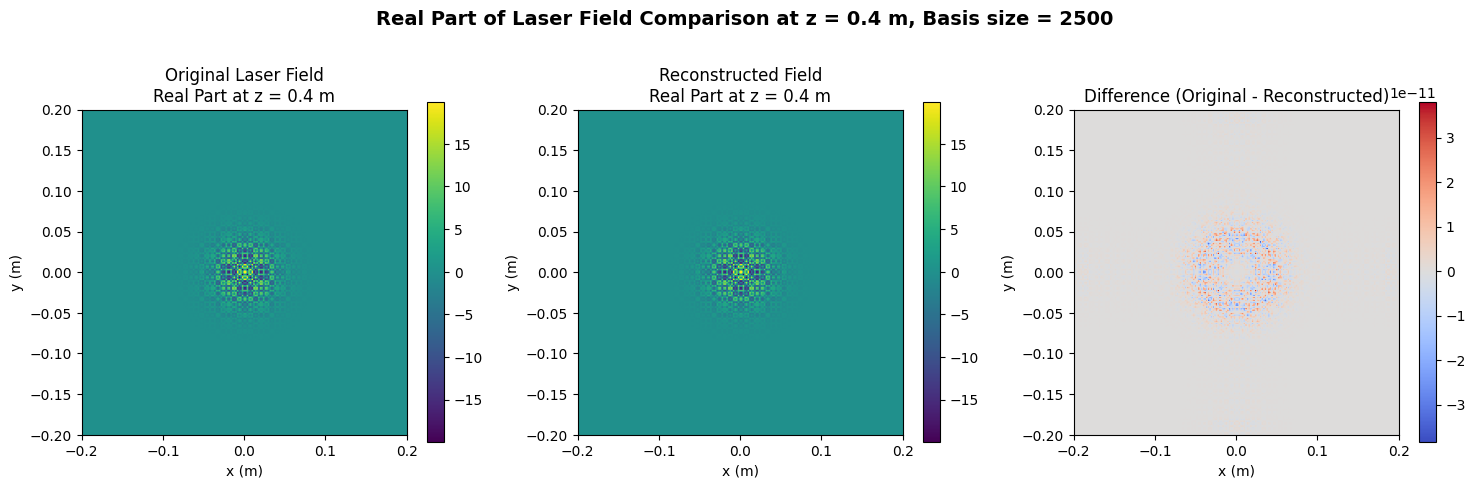

In [118]:
# Next we check if the two methods agree: 
z = 0.4
w0 = 1.65e-6
w0_mode = 2.3e-6
k = 2 * np.pi/488e-9
theta = 0
basis_size = 50

# print(u(10*w0, 10*w0, z, w0, k, m = 0, n = 0))
# print(projection(10*w0, 10*w0, z, w0, w0_mode, k, theta))
# print(w(z, w0, k))
# print(k * w0_mode**2 / 2)


u_fixed = lambda x, y: u(x, y, z, w0, k)
projection_fixed = lambda x, y: projection(x, y, z, w0, w0_mode, k, theta, basis_size)

x = np.linspace(-0.2, 0.2, 200)
y = np.linspace(-0.2, 0.2, 200)
X, Y = np.meshgrid(x, y)

# Evaluate on grid
U = u_fixed(X, Y)
E_vals = projection_fixed(X, Y)

# Plot magnitudes
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Compute shared scale limits
vmin = min(np.real(U).min(), np.real(E_vals).min())
vmax = max(np.real(U).max(), np.real(E_vals).max())
diff_vmin = np.real(E_vals - U).min()
diff_vmax = np.real(E_vals - U).max()

# Plot original field
im0 = axs[0].imshow(np.real(U), extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title('Original Laser Field\nReal Part at z = 0.4 m', fontsize=12)
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
fig.colorbar(im0, ax=axs[0], shrink=0.8)

# Plot reconstructed field
im1 = axs[1].imshow(np.real(E_vals), extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title('Reconstructed Field\nReal Part at z = 0.4 m', fontsize=12)
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('y (m)')
fig.colorbar(im1, ax=axs[1], shrink=0.8)

# Plot difference
im2 = axs[2].imshow(np.real(U - E_vals), extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', cmap='coolwarm', vmin=diff_vmin, vmax=diff_vmax)
axs[2].set_title('Difference (Original - Reconstructed)', fontsize=12)
axs[2].set_xlabel('x (m)')
axs[2].set_ylabel('y (m)')
fig.colorbar(im2, ax=axs[2], shrink=0.8)

# Final touches
plt.tight_layout()
plt.subplots_adjust(top=0.88)
fig.suptitle(f'Real Part of Laser Field Comparison at z = 0.4 m, Basis size = {basis_size**2}', fontsize=14, weight='bold')
plt.show()

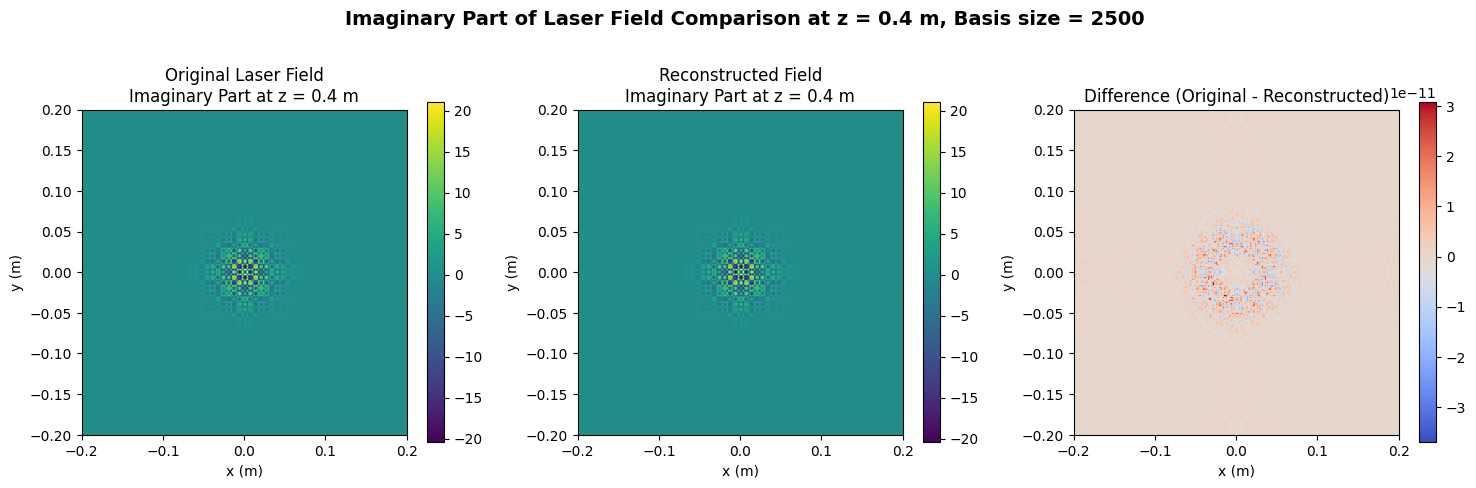

In [117]:
# Next we check if the two methods agree: 
z = 0.4
w0 = 1.65e-6
w0_mode = 2.3e-6
k = 2 * np.pi/488e-9
theta = 0
basis_size = 50

u_fixed = lambda x, y: u(x, y, z, w0, k)
projection_fixed = lambda x, y: projection(x, y, z, w0, w0_mode, k, theta, basis_size)

x = np.linspace(-0.2, 0.2, 200)
y = np.linspace(-0.2, 0.2, 200)
X, Y = np.meshgrid(x, y)

# Evaluate on grid
U = u_fixed(X, Y)
E_vals = projection_fixed(X, Y)

# Plot magnitudes
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Compute shared scale limits
vmin = min(np.imag(U).min(), np.imag(E_vals).min())
vmax = max(np.imag(U).max(), np.imag(E_vals).max())
diff_vmin = np.imag(E_vals - U).min()
diff_vmax = np.imag(E_vals - U).max()

# Plot original field
im0 = axs[0].imshow(np.imag(U), extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title('Original Laser Field\nImaginary Part at z = 0.4 m', fontsize=12)
axs[0].set_xlabel('x (m)')
axs[0].set_ylabel('y (m)')
fig.colorbar(im0, ax=axs[0], shrink=0.8)

# Plot reconstructed field
im1 = axs[1].imshow(np.imag(E_vals), extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title('Reconstructed Field\nImaginary Part at z = 0.4 m', fontsize=12)
axs[1].set_xlabel('x (m)')
axs[1].set_ylabel('y (m)')
fig.colorbar(im1, ax=axs[1], shrink=0.8)

# Plot difference
im2 = axs[2].imshow(np.imag(U - E_vals), extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', cmap='coolwarm', vmin=diff_vmin, vmax=diff_vmax)
axs[2].set_title('Difference (Original - Reconstructed)', fontsize=12)
axs[2].set_xlabel('x (m)')
axs[2].set_ylabel('y (m)')
fig.colorbar(im2, ax=axs[2], shrink=0.8)

# Final touches
plt.tight_layout()
plt.subplots_adjust(top=0.88)
fig.suptitle(f'Imaginary Part of Laser Field Comparison at z = 0.4 m, Basis size = {basis_size**2}', fontsize=14, weight='bold')
plt.show()

Next, we consider how individual HG modes propagate through an ideal thin lens by using the $ABCD$ ray transfer matrices. But first, we establish a coordinate system, with the lens at $z = 0$, the upstream focal plane at $z = -f$, and the downstream focal plane at $z = f$.

We wish to calculate the position of the new waist, denoted $z_{waist}$, as well as the spot size at the new waist, denoted $w'_0$. We work with the complex parameter $q(z)$, which has the following property:
$$
\begin{align}
    q(z) &= z + i z_R \\
    \frac{1}{q(z)} &= \frac{1}{R(z)} - \frac{i \lambda}{\pi w_0^2}
\end{align}
$$
Note that $z_R$ is the Rayleigh range and can be calculated as $z_R = \frac{k w_0^2}{2}$. $R(z)$ is the radius of curvature at $z$, and $w(z)$ is of course the spot size at $z$. Also note that the above two formulas assume that the waist is at z = 0, which is not the case in our coordinate system.

In the coordinate system we just set up, we have 
$$q(-f) = i z_R,$$ 
since the radius of curvature is infinite at the waist, which we assume to be at the fiber tip, which is at the downstream focal plane of the lens. 
We can then easily see that
$$q(0)_- = f + i z_R$$
The ABCD matrix of a thin lens is given by
$$
\begin{bmatrix}
1 & 0 \\
-\dfrac{1}{f} & 1
\end{bmatrix},
$$
and it transforms the parameter $q$ in the following manner:
$$
q_{\text{out}} = \frac{A q_{\text{in}} + B}{C q_{\text{in}} + D} = \frac{q_{\text{in}}}{1 - \dfrac{q_{\text{in}}}{f}}.
$$
Therefore we have 
$$
q(0)_+ = -f + i \frac{f^2}{z_R}.
$$
After propagating for another distance $z$ beyond the lens, we have 
$$
q(z) = (-f + z) + i \frac{f^2}{z_R}.
$$
To find the position of the new waist, we look for a $z$ where the radius of curvature is inifinite, which means that $Re\{q(z)\} = 0$, which is true if and only if $Re\{q(z)\} = 0$. Clearly, the only candidate is 
$$ z = f.$$ 
Thus, a Gaussian beam whose waist is at the upstream focal plane will become a new Gaussian beam whose waist is at the downstream focal plane. 

The next question is: What is the spot size $w'_0$ at the new waist? Since $q(f) = i \frac{f^2}{z_R}$, we have
$$
\frac{1}{q(f)} =  - \frac{i z_R}{f^2} = -\frac{i \lambda}{\pi {w'}_0^2}
$$
by solving this we obtain
$$
w'_0 = \frac{\lambda f}{\pi w_0},
$$
as expected. 

Since all $HG$ modes are parameterized by this single $q(z)$ complex parameter, we expect all $HG$ modes to behave the same when travelling through this lens. 


The full work flow is therefore in the code below and can be quite simplified. Given an initial laser beam at the fiber tip with some tilt, all we need to know is the distance between the exit AOM face and the downstream focal plane of the ideal thin lens. 

In [165]:
# analytical result derived by chat_gpt, which seems to be correct after checking the numerics
def analytical_integral_y(w0, w0_mode, n):
    q = 1/w0**2 + 1/w0_mode**2
    Delta = - (w0_mode**2 - w0**2) / (w0_mode**2 + w0**2)
    if n % 2 == 1:
        return 0
    if n % 2 == 0:
        p = int(n/2)
        result = np.sqrt(np.pi/q) * math.factorial(2*p)/math.factorial(p) * (Delta)**p
        return result
    
def analytical_integral_x(w0: float,
                w0_mode: float,
                k: float,
                theta: float,
                m: int) -> complex:
    
    if m < 0 or int(m) != m:
        raise ValueError("m must be a non-negative integer")
    
    # Core scalars
    q      = 1.0 / w0**2 + 1.0 / w0_mode**2             # real, > 0
    s      = 1j * k * np.sin(theta)                     # purely imaginary
    alpha  = np.sqrt(2.0) / w0_mode
    Delta  = alpha**2 / q - 1.0                         # can be ±
    mu     = alpha * s / q

    # Prefactor  √(π/q)  exp(s² / 4q)  m!
    pref   = np.sqrt(np.pi / q) * np.exp(s**2 / (4.0 * q)) * math.factorial(m)

    # Finite series  Σ_{j=0}^{⌊m/2⌋}  Δ^j / j! · μ^{m-2j} / (m-2j)!
    series = 0.0 + 0.0j
    for j in range(m // 2 + 1):
        series += (Delta ** j) / math.factorial(j) * (mu ** (m - 2 * j)) / math.factorial(m - 2 * j)

    return pref * series

def c_mn(w0, w0_mode, k, theta, m, n):
    E0=np.sqrt(2/(np.pi * (w0)**2))
    denominator = np.pi * w0_mode**2 * 2**(m+n) * math.factorial(m) * math.factorial(n)
    const = E0 * np.sqrt(2/denominator)
    return const * analytical_integral_x(w0, w0_mode, k, theta, m) * analytical_integral_y(w0, w0_mode, n)

# the waist as a function of z
def w(z, w0_mode, k):
    zR = k * w0_mode**2 / 2
    w_z = w0_mode * np.sqrt(1 + (z/zR)**2)
    return w_z

# the radius of curvature as a function of z
def R(z, w0_mode,  k):
    zR = k * w0_mode**2 / 2
    R_z = z * (1 + (zR/z)**2)
    return R_z

# the Guoy phase as a function of z
def psi(z, w0_mode, k, m = 0, n = 0):
    zR = k * w0_mode**2 / 2
    psi_z = (m + n + 1) * np.arctan2(z, zR)
    return psi_z

def u(x, y, z, w0_mode, k, m = 0, n = 0):
    denominator = np.pi * w0_mode**2 * 2**(m+n) * math.factorial(m) * math.factorial(n)
    norm = np.sqrt(2/denominator)
    u = norm * w0_mode/w(z, w0_mode, k) * hermite(m)(np.sqrt(2) * x / w(z, w0_mode, k)) * hermite(n)(np.sqrt(2) * y / w(z, w0_mode, k)) * np.exp(-(x**2 + y**2)/w(z, w0_mode, k)**2) * np.exp(-1j * k * (x**2 + y**2)/(2 * R(z, w0_mode, k))) * np.exp(1j*psi(z, w0_mode, k, m, n)) * np.exp(-1j*k*z)
    return u

# next, check if correct.
def projection(x, y, z, w0, w0_mode, k, theta, basis_size = 10):
    result = 0
    for m in range(basis_size): 
        for n in range(basis_size):
            result += c_mn(w0, w0_mode, k, theta, m, n) * u(x, y, z, w0_mode, k, m, n)
            # print(c_mn(w0, w0_mode, k, theta, m, n))
    return result


def UE_f(x, y, z, w0, w0_mode, k, theta, f, basis_size = 10):
    w0_new = 2 * f / (k * w0_mode)
    result = 0
    xi = z - 2 * f
    for m in range(basis_size):
        for n in range(basis_size):
            result += c_mn(w0, w0_mode, k, theta, m, n) * u(x, y, xi, w0_new, k, m, n)
    return result










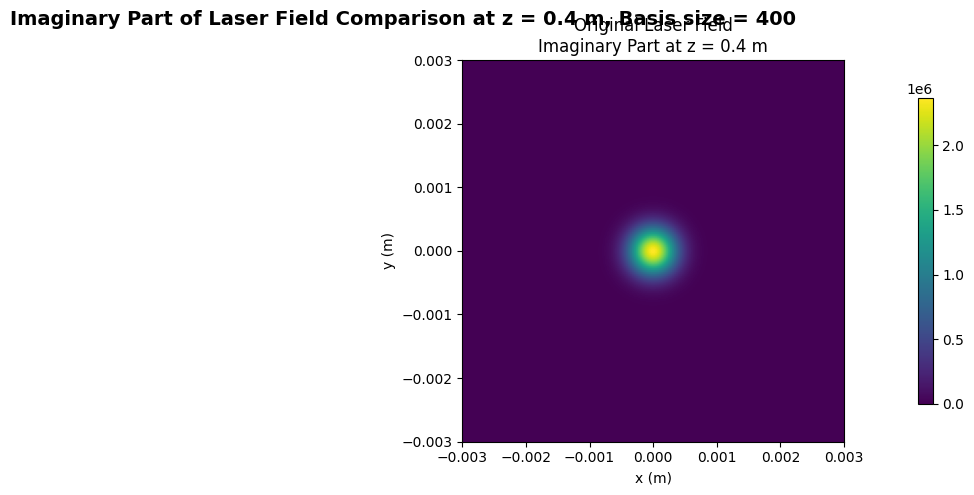

In [170]:
z = 11.01e-3
w0 = 1.65e-6
w0_mode = 1.65e-6
k = 2 * np.pi/488e-9
theta = 0
f = 5.5e-3
basis_size = 20
xi = z - 2 * f
w0_new = 2 * f / (k * w0_mode)


UE_f_fixed = lambda x, y: UE_f(x, y, z, w0, w0_mode, k, theta, f, basis_size)
# UE_f_fixed = lambda x, y: u(x, y, xi, w0_new, k, m=0, n=0)

x = np.linspace(-0.3e-2, 0.3e-2, 200)
y = np.linspace(-0.3e-2, 0.3e-2, 200)
X, Y = np.meshgrid(x, y)

U = UE_f_fixed(X, Y)

# Plot magnitudes
fig, axs = plt.subplots(1, 1, figsize=(15, 5))


# Plot original field
im0 = axs.imshow(np.abs(U)**2, extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', cmap='viridis')
axs.set_title('Original Laser Field\nImaginary Part at z = 0.4 m', fontsize=12)
axs.set_xlabel('x (m)')
axs.set_ylabel('y (m)')
fig.colorbar(im0, ax=axs, shrink=0.8)

# Final touches
plt.tight_layout()
plt.subplots_adjust(top=0.88)
fig.suptitle(f'Imaginary Part of Laser Field Comparison at z = 0.4 m, Basis size = {basis_size**2}', fontsize=14, weight='bold')
plt.show()

In [ ]:
# a numerical method to take the inner product of two arbitrary 2D functions

import numpy as np
from scipy.integrate import dblquad


def compute_inner_product(A, B, L=100, tol=1e-8, clip_x=None):
    """
    Compute the inner product ∫∫ A*(x,y) B(x,y) dx dy over [-L, L] x [-L, L]
    using adaptive quadrature, with optional manual split at discontinuity x=clip_x.
    Assumes A and B are callable functions of (x, y) and decay exponentially.
    If clip_x is given and assumes B=0 for x > clip_x (Heaviside clip), integrates only x <= clip_x.

    Parameters:
    - A, B: callable functions, each taking (x, y) and returning complex or real.
    - L: float, half-width of integration limits (default 10.0).
    - tol: float, absolute/relative tolerance for quadrature (default 1e-8).
    - clip_x: float or None, x-location of discontinuity (default None for full integral).

    Returns:
    - complex: The approximated inner product.
    """
    
    def integrand_real(y, x):
        conj_A = np.conj(A(x, y))
        prod = conj_A * B(x, y)
        return np.real(prod)

    def integrand_imag(y, x):
        conj_A = np.conj(A(x, y))
        prod = conj_A * B(x, y)
        return np.imag(prod)

    # Determine x limits based on clip
    # if clip_x is None:
    x_min, x_max = -L, L
    # else:
    #     x_min, x_max = -L, min(clip_x, L)  # Integrate only x >= clip_x (assuming B=0 left)

    # Integrate real and imaginary parts separately
    real_part, real_err = dblquad(integrand_real, x_min, x_max, lambda x: -L, lambda x: L, epsabs=tol, epsrel=tol)
    imag_part, imag_err = dblquad(integrand_imag, x_min, x_max, lambda x: -L, lambda x: L, epsabs=tol, epsrel=tol)

    inner_product = real_part + 1j * imag_part
    total_err = real_err + imag_err  # Rough error estimate (magnitude)

    print(f"Estimated error: {total_err:.2e}")
    return inner_product

def clipped_gaussian(x, y, w_gauss, clip_x):
    #normalization constant
    const = np.sqrt(2/(np.pi * w_gauss**2))
    gaussian = const * np.exp(-(x**2 + y**2)/w_gauss**2)
    return gaussian if x <= clip_x else 0.0  # Clipped at x=0.5 (Heaviside-like)


z = 0.4
w0 = 1.65e-6
w0_mode = 1.65e-6
k = 2 * np.pi/488e-9
theta = 0
f = 5.5e-3
basis_size = 20
xi = z - 2 * f
w0_new = 2 * f / (k * w0_mode)
print(w0_new)
clip_x = -0.35e-3
w_gauss = 0.35e-3

UE_f_z = lambda x, y: UE_f(x, y, z, w0, w0_mode, k, theta, f, basis_size)
clipped_gaussian_z = lambda x, y: clipped_gaussian(x, y, w_gauss, clip_x)




print(w(xi, w0_new, k))
# Compute with split at clip_x=0.5

result = compute_inner_product(clipped_gaussian_z, clipped_gaussian_z, L=max(3 * w(xi, w0_new, k), 3 *  w_gauss), clip_x=clip_x)
print(f"Inner product: {result}")











0.0005177840815256328
0.0005307723100175284
Estimated error: 6.88e-08
Inner product: (0.022750131963029815+0j)


We now have the capability to calculate inner products at the the AOM exit face. Next is to figure out how to extract the phase profile from this inner product. I can make the clip_x variable be a function of time and the acoustic velocity.

Questions:

1. What are some good numerical methods to compute the inner product? Currently using the quadrature method. 
2. Should I take into account the effect of the mirrors and the NPBC on the equation for the electric field? 